**Mean Shift** — это алгоритм кластеризации, основанный на поиске мод распределения (плотности) без предварительного задания количества кластеров.

Mean Shift сдвигает точки в направлении наибольшей плотности, используя ядерную оценку плотности (KDE). Алгоритм находит локальные максимумы плотности, которые становятся центрами кластеров.

**Алгоритм**:
1) Берём точку.
2) Строим вокруг неё окно (радиус).
3) Считаем среднее всех точек внутри окна.
4) Сдвигаем окно в это среднее.
5) Повторяем, пока окно почти не перестанет двигаться.
6) Точки, которые сошлись в одну область -> один кластер.

**Плюсы**:
- Не нужно задавать число кластеров
- Находит кластеры любой формы
- Основан на плотности

**Минусы**:
- Медленный на больших данных
- Нужно выбирать bandwidth
- Плохо работает в high-dimensional data

In [2]:
# Блок с используемыми библиотеками
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/spotify_tracks.csv", sep=",")
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [4]:
# Блок с предварительной обработкой датасета

df.info()

# заменим жанры на категории

df_genre = df.copy()
df_genre = pd.get_dummies(df, columns=['genre'], drop_first=True)

df_tr = df_genre
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  str    
 1   track_name        50000 non-null  str    
 2   artist_name       50000 non-null  str    
 3   album_name        50000 non-null  str    
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  str    
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float64
 17  temp

In [5]:
X = df_tr.drop(['track_id', 'track_name', 'artist_name', 'album_name', 'release_year', 'time_signature', 'duration_ms', 'popularity'], 
               axis=1) 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

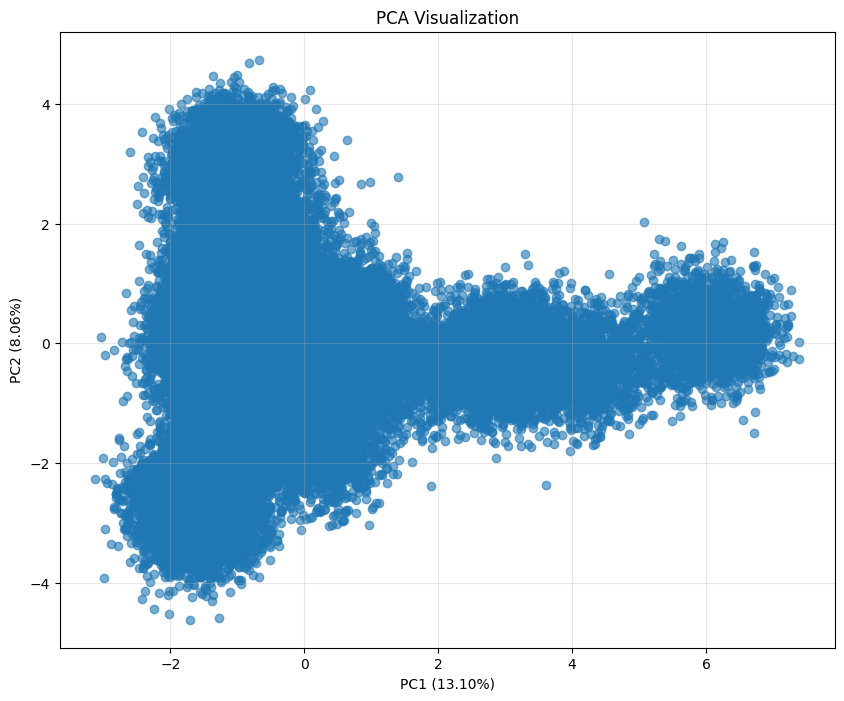

In [6]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA Visualization')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
bandwidth = estimate_bandwidth(pca_result, quantile=0.2, n_samples=500)
print("Bandwidth:", bandwidth)

Bandwidth: 1.7768068070817682


In [8]:
ms = MeanShift(bandwidth=bandwidth)
ms.fit(pca_result)

labels = ms.labels_
cluster_centers = ms.cluster_centers_

n_clusters = len(np.unique(labels))
print("Number of clusters:", n_clusters)

Number of clusters: 2


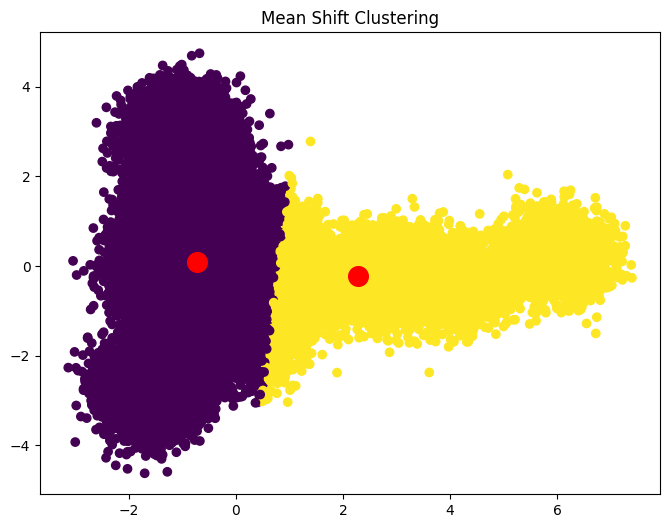

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=labels, cmap='viridis')
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], c='red', s=200)
plt.title("Mean Shift Clustering")
plt.show()

Обычно, Mean Shift плохо работает на больших датасетах, что мы и наблюдаем. 

In [11]:
score = silhouette_score(X_scaled, n_clusters)
print("Silhouette Score:", score)

InvalidParameterError: The 'labels' parameter of silhouette_score must be an array-like. Got 2 instead.